In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 读取数据
df = pd.read_csv('planets.csv')
df.head()

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


In [3]:
missing = df.isnull().sum()
missing_pct = missing / len(df) * 100
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(missing_df)

                missing_count  missing_pct
mass                      522    50.434783
distance                  227    21.932367
orbital_period             43     4.154589


In [5]:
# 创建 orbital_period 缺失标识
df['op_missing'] = df['orbital_period'].isnull()

# 使用 distance 进行比较（distance 有较多非缺失）
distance_with_op = df.loc[~df['op_missing'], 'distance'].mean()
distance_without_op = df.loc[df['op_missing'], 'distance'].mean()
print(f"有 orbital_period 的样本 distance 均值: {distance_with_op:.2f}")
print(f"无 orbital_period 的样本 distance 均值: {distance_without_op:.2f}")

有 orbital_period 的样本 distance 均值: 219.12
无 orbital_period 的样本 distance 均值: 1354.16


In [6]:
year_with_op = df.loc[~df['op_missing'], 'year'].mean()
year_without_op = df.loc[df['op_missing'], 'year'].mean()
print(f"有 orbital_period 的样本 year 均值: {year_with_op:.2f}")
print(f"无 orbital_period 的样本 year 均值: {year_without_op:.2f}")

有 orbital_period 的样本 year 均值: 2009.03
无 orbital_period 的样本 year 均值: 2009.95


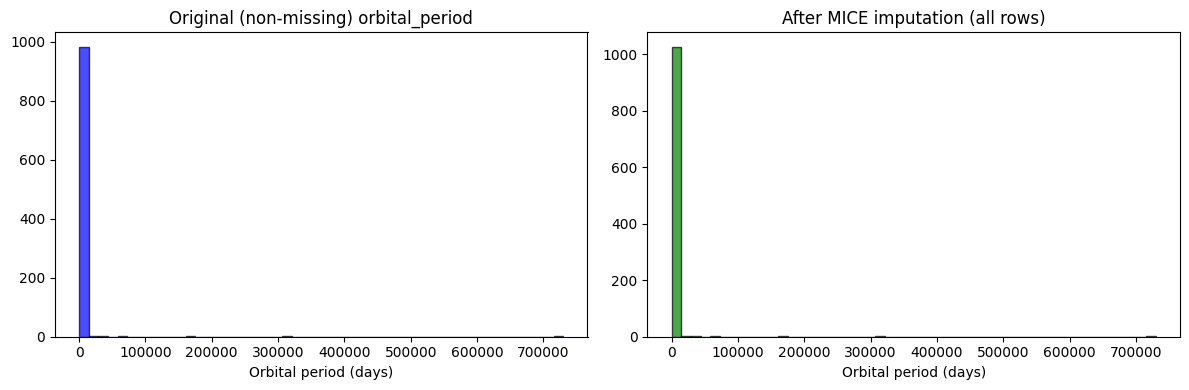

In [7]:
# 选择数值列
numeric_cols = ['number', 'orbital_period', 'mass', 'distance', 'year']
df_num = df[numeric_cols].copy()

# MICE 插补
mice_imputer = IterativeImputer(max_iter=10, random_state=42)
df_mice = pd.DataFrame(mice_imputer.fit_transform(df_num), columns=numeric_cols)

# 绘制原始（非缺失）与插补后分布
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# 原始非缺失 orbital_period
orig_op = df_num['orbital_period'].dropna()
axes[0].hist(orig_op, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('Original (non-missing) orbital_period')
axes[0].set_xlabel('Orbital period (days)')
# 插补后全部
axes[1].hist(df_mice['orbital_period'], bins=50, alpha=0.7, color='green', edgecolor='black')
axes[1].set_title('After MICE imputation (all rows)')
axes[1].set_xlabel('Orbital period (days)')
plt.tight_layout()
plt.show()

In [8]:
# 准备数据：只保留 orbital_period 非缺失的行
df_reg = df[numeric_cols].dropna(subset=['orbital_period']).copy()
X = df_reg[['number', 'mass', 'distance', 'year']]
y = df_reg['orbital_period']

# 定义两种管道
pipelines = {
    'Mean Imputation': Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),   # 可选，有利于回归
        ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
    ]),
    'MICE Imputation': Pipeline([
        ('imputer', IterativeImputer(max_iter=10, random_state=42)),
        ('scaler', StandardScaler()),
        ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
    ])
}

# 交叉验证评分（负均方误差）
from sklearn.metrics import mean_squared_error, make_scorer
rmse_scorer = make_scorer(mean_squared_error, squared=False)  # RMSE

for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X, y, cv=5, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-scores)
    print(f"{name}: Mean RMSE = {rmse_scores.mean():.2f} (+/- {rmse_scores.std():.2f})")

Mean Imputation: Mean RMSE = 19148.73 (+/- 18181.39)


D:\Collage\python\Python\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


MICE Imputation: Mean RMSE = 19556.68 (+/- 17634.11)
